Created by Sanish Bhochhibhoya (03/08/2025)

#### Steps:
1) Boundary Creation
2) Utils Creation
3) Creating a domain3D for each
4) merging domain3d
5) Soil and Util types random generation
6) GWT
7) Mean and Std. of properties
8) Spatial

#### To do:
1) SpatialCorrelationMethod2
3) Saving the docs
4) adjustment to different platform like SPECFEM3D, GPRMax

In [17]:
import geomodgen2d.boundary_creator as boundary_defn
import geomodgen2d.general_functions as f
import geomodgen2d.lithological_domain2d as lithological_domain2d
import geomodgen2d.utils_2d as utils_2d
import geomodgen2d.utils_3d_functions as utils_3d_f
# import geomodgen3d.utils_3d as utils_3d
import geomodgen2d.material_properties as material_properties
import geomodgen2d.generated_profiles2d as generated_profiles2d
from geomodgen2d.random_generators import RandomGenerator
import geomodgen2d.material_domain2d as material_domain2d
import geomodgen2d.spatial_simulation2d as spatial_simulation2d
# import geomodgen2d.time_memory_recorder as time_memory_recorder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

def get_material_prop_instance_from_pd(main_property_name, feature_id, pd_dataframe, wet_a_colname, wet_b_colname, dry_a_colname, dry_b_colname, rnd_gen, cov_distribution = None, cov_type='cov'):
    material_property_set_instance = material_properties.MaterialPropertySet(main_property_name, feature_id)
    for material_name in pd_dataframe.index.tolist():
        # print(material_name)
        wet_a, wet_b = pd_dataframe[wet_a_colname].loc[material_name], pd_dataframe[wet_b_colname].loc[material_name]
        dry_a, dry_b = pd_dataframe[dry_a_colname].loc[material_name], pd_dataframe[dry_b_colname].loc[material_name]

        assert not pd.isna(wet_a), f"wet_a for {material_name} must be a number"
        assert not pd.isna(wet_b), f"wet_a for {material_name} must be a number"
        wet_mean_distribution = RandomGenerator(rnd_gen).uniform(wet_a, wet_b)
        wet_prop = material_properties.PropertyDistribution(f'{main_property_name}_wet/both', wet_mean_distribution, cov_distribution, stdev_type=cov_type)

        dry_mean_distribution = None
        if pd.isna(dry_a) or pd.isna(dry_b): 
            dry_prop = None
        else:
            dry_mean_distribution = RandomGenerator(rnd_gen).uniform(dry_a, dry_b)
            dry_mean_distribution.generate()[0]
            dry_prop = material_properties.PropertyDistribution(f'{main_property_name}_dry', dry_mean_distribution, cov_distribution, stdev_type=cov_type)
        
        material_property_set_instance.add_material(material_name, wet_prop, dry_prop)
    return material_property_set_instance

In [8]:
model_sett={
    'x_span':5,
    'y_span':5,
    'z_span':3,
    'del_xy_spatial':0.2,    #del_y value for boundary generation and spatial 
    'del_z_spatial':0.2,
    'del_xy_final': 0.1,  #refining del_z for utilities generation
    'del_z_final': 0.1,
    'refine_interp_method':'linear',
    'random_seed':3,
    'spatial_theta_x':100,
    'spatial_theta_y':100,
    'spatial_theta_z':0.5,
}

boundary_sett= {'flag_filter':True, 'flag_processing':True,
    'generator_settings_dict':{
                 'max_del_z_per_m':1.5,  
                 'generator_option':'uniform',
                },
    'filter_settings_dict': {
                 'filter_window_length':7, #21 #must be odd
                 'filter_polyorder':3,
                        },
    'boundary_overlap_bottom_priority':True,
    'random_init_boundary_option':'random_sort', #options: 'random_sum', 'random_sort', 'equidistant'
    
    }


n_layers = 3

r_seed = model_sett['random_seed']
rnd_gen = np.random.default_rng(seed=r_seed)


soil_props_csv = pd.read_csv('data/soil_properties.csv', index_col=0).apply(pd.to_numeric, errors='coerce')
utils_props_csv = pd.read_csv('data/utils_properties.csv', index_col=0).apply(pd.to_numeric, errors='coerce')

material_list = soil_props_csv.index.tolist()
utils_list = utils_props_csv.index.tolist()

In [27]:

soil_sett={
    'n_layer_dist':RandomGenerator(rnd_gen).discrete_choice([1,2], p = [0.5,0.5]),
    'soil_type':RandomGenerator(rnd_gen).discrete_choice(material_list),
    'gwt_depth': RandomGenerator(rnd_gen).uniform(0, model_sett['z_span']),
    # 'Vs_soils_cov_range':{1200:RandomGenerator(rnd_gen).uniform(0.05, 0.15), 
    #                       760:RandomGenerator(rnd_gen).uniform(0.05, 0.20), 
    #                       460:RandomGenerator(rnd_gen).uniform(0.05, 0.20), 
    #                       0:RandomGenerator(rnd_gen).uniform(0.10, 0.20)},

    'cov_dc_ec': RandomGenerator(rnd_gen).constant(0.05),
    'cov_vs_rho': RandomGenerator(rnd_gen).constant(0.05),
    
    'min_vs':30,  #Not adopted yet
    # 'min_vp':60,
}

utilities_sett={
    'n_utils': RandomGenerator(rnd_gen).discrete_choice([0,1,2], [0.2, 0.5, 0.3]),
    'utils_shape': RandomGenerator(rnd_gen).discrete_choice(['circ2d', 'rect2d',], [1/2, 1/2]),
    'r_utils2d':RandomGenerator(rnd_gen).uniform(0.1, 0.5), 
    'lh_utils2d':RandomGenerator(rnd_gen).uniform(0.2, 1), 
    'lbh_utils3d':RandomGenerator(rnd_gen).uniform(0.2, 2), 
    'depth_top_dist':RandomGenerator(rnd_gen).discrete2continuous_pdf([0,3], p = [1,.2], new_del_x = 0.1), #Continuous distribution: discrete to be converted into continuous: also

    'utils_type':RandomGenerator(rnd_gen).discrete_choice(utils_list),
    
    # 'vs_dist':RandomGenerator(rnd_gen).uniform(30, 70),
    # 'vp_dist':RandomGenerator(rnd_gen).uniform(340, 1500), # Direct Vp (Vp; air to Vp,water = 1500)
    # 'density_dist':RandomGenerator(rnd_gen).uniform(800, 2000), #to discuss
}
soil_sett['vs'] = get_material_prop_instance_from_pd('vs', 'def', soil_props_csv, 'vs_wet_a', 'vs_wet_b', 'vs_dry_a', 'vs_dry_b', rnd_gen,
                                                     cov_distribution = soil_sett['cov_vs_rho'], cov_type='cov')
soil_sett['miu'] = get_material_prop_instance_from_pd('miu', 'def', soil_props_csv, 'miu_wet_a', 'miu_wet_b', 'miu_dry_a', 'miu_dry_b', rnd_gen)
soil_sett['rho'] = get_material_prop_instance_from_pd('rho', 'def', soil_props_csv, 'rho_wet_a', 'rho_wet_b', 'rho_dry_a', 'rho_dry_b', rnd_gen,
                                                     cov_distribution = soil_sett['cov_vs_rho'], cov_type='cov')
soil_sett['dc'] = get_material_prop_instance_from_pd('dc', 'def', soil_props_csv, 'dc_wet_a', 'dc_wet_b', 'dc_dry_a', 'dc_dry_b', rnd_gen,
                                                     cov_distribution = soil_sett['cov_dc_ec'], cov_type='cov')
soil_sett['ec'] = get_material_prop_instance_from_pd('ec', 'def', soil_props_csv, 'ec_wet_a', 'ec_wet_b', 'ec_dry_a', 'ec_dry_b', rnd_gen,
                                                     cov_distribution = soil_sett['cov_dc_ec'], cov_type='cov')

utilities_sett['vs'] = get_material_prop_instance_from_pd('vs', 'U_', utils_props_csv, 'vs_wet_a', 'vs_wet_b', 'vs_dry_a', 'vs_dry_b', rnd_gen)
utilities_sett['miu'] = get_material_prop_instance_from_pd('miu', 'U_', utils_props_csv, 'miu_wet_a', 'miu_wet_b', 'miu_dry_a', 'miu_dry_b', rnd_gen)
utilities_sett['rho'] = get_material_prop_instance_from_pd('rho', 'U_', utils_props_csv, 'rho_wet_a', 'rho_wet_b', 'rho_dry_a', 'rho_dry_b', rnd_gen)
utilities_sett['dc'] = get_material_prop_instance_from_pd('dc', 'U_', utils_props_csv, 'dc_wet_a', 'dc_wet_b', 'dc_dry_a', 'dc_dry_b', rnd_gen)
utilities_sett['ec'] = get_material_prop_instance_from_pd('ec', 'U_', utils_props_csv, 'ec_wet_a', 'ec_wet_b', 'ec_dry_a', 'ec_dry_b', rnd_gen)

In [39]:
addn_props = material_properties.AllAdditionalProperties()
addn_props.add_addn_property('n_layers', soil_sett['n_layer_dist'])
addn_props.add_addn_property('n_utils', utilities_sett['n_utils'])
addn_props.add_addn_property('utils_shape', utilities_sett['utils_shape'])
addn_props.add_addn_property('soil_type', soil_sett['soil_type'])
addn_props.add_addn_property('gwt_depth', soil_sett['gwt_depth'])
addn_props.add_addn_property('depth_top_utils', utilities_sett['depth_top_dist'])
addn_props.add_addn_property('utlls_shape', utilities_sett['depth_top_dist'])
addn_props.add_addn_property('r_utils2d', utilities_sett['r_utils2d'])
addn_props.add_addn_property('lh_utils2d', utilities_sett['lh_utils2d'])
addn_props.add_addn_property('lbh_utils3d', utilities_sett['lbh_utils3d'])
addn_props.add_addn_property('utils_type', utilities_sett['utils_type'])
addn_props.print()

Additional_Properties: dict_keys(['n_layers', 'n_utils', 'utils_shape', 'soil_type', 'gwt_depth', 'depth_top_utils', 'utlls_shape', 'r_utils2d', 'lh_utils2d', 'lbh_utils3d', 'utils_type'])


In [40]:
importlib.reload(material_properties)

features_w_id = {'def': 'soil', 'U_':'utils'}
main_props = material_properties.AllMainProperties(features_w_id)
main_props.add_main_property('vs', [soil_sett['vs'], utilities_sett['vs']], description = 'Shear wave velocity in m/s')
main_props.add_main_property('miu', [soil_sett['miu'], utilities_sett['miu']], description = "Poisson's ratio")
main_props.add_main_property('rho', [soil_sett['rho'], utilities_sett['rho']], description = "Density")
main_props.add_main_property('dc', [soil_sett['dc'], utilities_sett['dc']], description = "Dielectric Constant")
main_props.add_main_property('ec', [soil_sett['ec'], utilities_sett['ec']], description = "Electric Conductivity in mS/s")
main_props.print()

Main_Properties: dict_keys(['vs', 'miu', 'rho', 'dc', 'ec'])
features_w_id: {'def': 'soil', 'U_': 'utils'}
---------------------------
Property Name: vs
{'description': 'Shear wave velocity in m/s',
 'def': {'layer0_val': 0,
         'Fat Clays': {'both': <geomodgen2d.material_properties.PropertyDistribution object at 0x000002158FF35210>},
         'Lean Clays': {'both': <geomodgen2d.material_properties.PropertyDistribution object at 0x000002158FEEF990>},
         'Silts': {'both': <geomodgen2d.material_properties.PropertyDistribution object at 0x000002158FC02590>},
         'Loose Sand': {'both': <geomodgen2d.material_properties.PropertyDistribution object at 0x000002158FF1A8D0>},
         'Dense Sand': {'both': <geomodgen2d.material_properties.PropertyDistribution object at 0x000002158FE0F5D0>},
         'Gravel': {'both': <geomodgen2d.material_properties.PropertyDistribution object at 0x000002158FF1C290>},
         'Weathered Rock': {'both': <geomodgen2d.material_properties.Property

In [41]:
main_props.main_properties['vs'].generate_sample_dict('def', 'Fat Clays')

{'both': {'mean': 147.5506477855684,
  'mean_bm': 0,
  'stdev/cov': 0.05,
  'stdev_type': 'cov'},
 'layer0_air': {'mean': 0}}

Provided reference x_val (0) is not available in boundary x_ranges: [0.1 0.3 0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3 2.5 2.7 2.9 3.1 3.3 3.5
 3.7 3.9 4.1 4.3 4.5 4.7 4.9]. So using nearest value (i.e., 0.1)
[1.191209  2.5458107]


<Axes: xlabel='Distance', ylabel='Depth'>

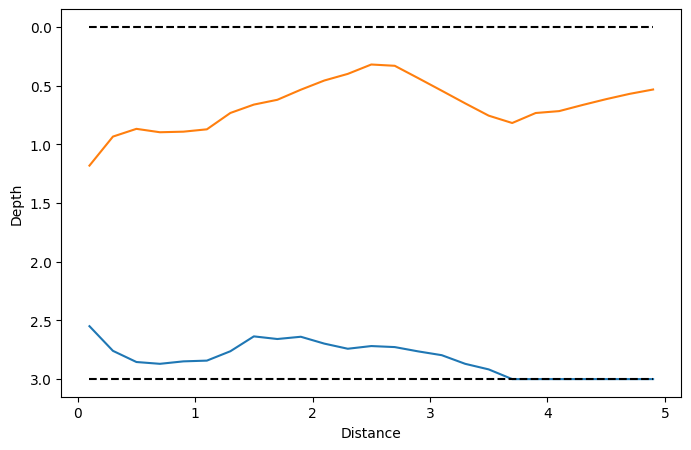

In [9]:
importlib.reload(boundary_defn)
boundary = boundary_defn.BoundaryCreator(model_sett['x_span'], model_sett['z_span'], model_sett['del_xy_spatial'], model_sett['del_z_spatial'], n_layers)
method = 'random_sum'
# method = 'random_sort'
method = 'equidistant'

boundary.gen_using_def_process(boundary_sett, rnd_no=rnd_gen)
boundary.plot_boundary()

[0.1 0.3 0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3 2.5 2.7 2.9 3.1 3.3 3.5
 3.7 3.9 4.1 4.3 4.5 4.7 4.9]


'Boundary'

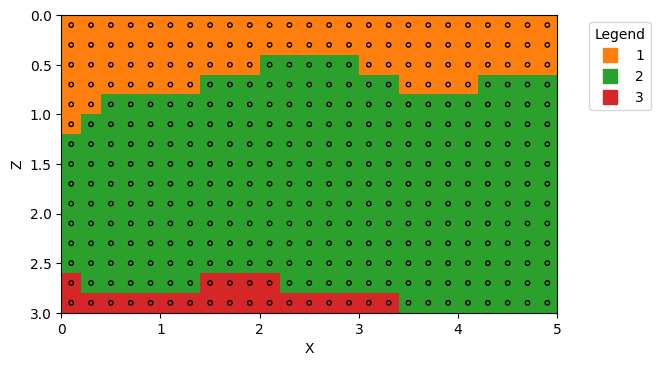

In [72]:
importlib.reload(f)
importlib.reload(lithological_domain2d)
name = 'asdf'
lit = lithological_domain2d.LithologicalDomain2D(model_sett['x_span'], model_sett['z_span'], model_sett['del_xy_spatial'], model_sett['del_z_spatial'], name)
gwt_d = addn_props.addn_properties['gwt_depth'].generate()[0]
lit.get_matrix_from_boundary(boundary, gwt_depth=gwt_d)
print(lit.x_ranges)
# lit.remeshing_layered_matrix(model_sett['x_span'], model_sett['y_span'], model_sett['z_span'], model_sett['del_xy_final'], model_sett['del_xy_final'], model_sett['del_z_final'])
lit.plot2d(scatter_point_size = 10)
lit.utils_description

[4.795829855197003, 0.0]
[2.549434827843883, 1.5]
Adjusted size of rectangle is 0.9 x 0.6000000000000001, changed from 0.894163853366545x0.5944639543222754
[0.3205964920471571, 0.6000000000000001]


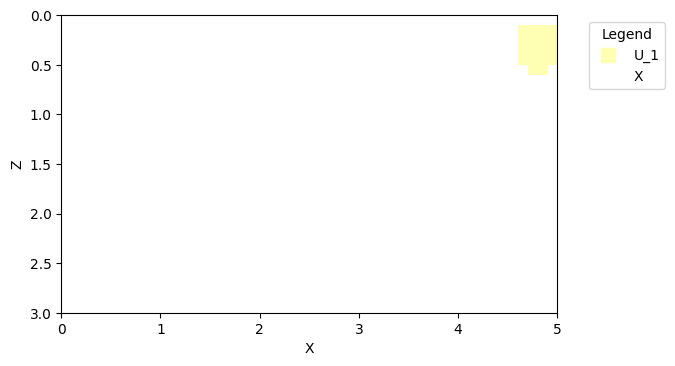

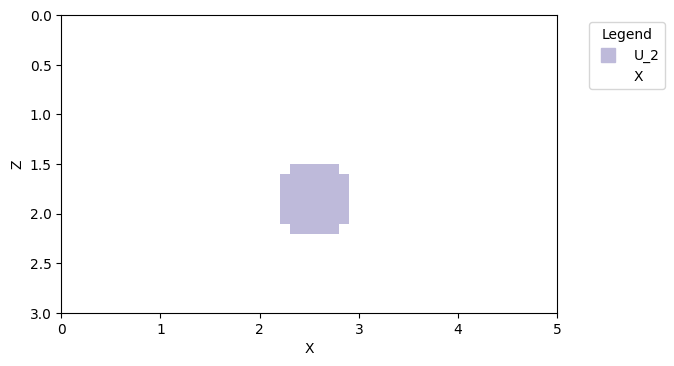

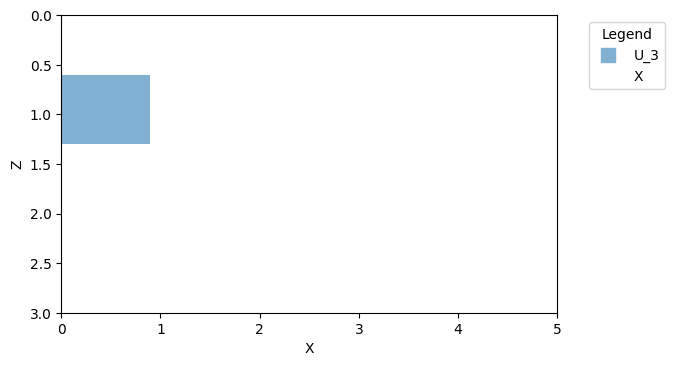

In [73]:
import matplotlib.pyplot as plt
importlib.reload(utils_2d)
importlib.reload(f)
importlib.reload(utils_3d_f)
importlib.reload(lithological_domain2d)

surf=None
ux_coord = RandomGenerator(rnd_gen).uniform(0, model_sett['x_span'])
uy_coord = RandomGenerator(rnd_gen).uniform(0, model_sett['x_span'])
uz_rotation = RandomGenerator(rnd_gen).uniform(0, 90)

n_utils = 3;addn_props.addn_properties['n_utils'].generate()[0]
d_utils = addn_props.addn_properties['depth_top_utils'].generate((n_utils,))
util_shapes = addn_props.addn_properties['utils_shape'].generate((n_utils,))

r_circ = [.2, .4, 1.5]
# d_circ = [1,2,2.3]
util_lit_list = []
util_id = 0
for d, u_shape in zip(d_utils, util_shapes):
# for r, d in zip(r_circ, d_circ):
    util_id+=1
    utils_2d_instance = utils_2d.Utils2D(del_x = model_sett['del_xy_final'], del_z = model_sett['del_z_final'], refining_factor=4)
    x_rnd = ux_coord.generate()[0]
    z_rot = uz_rotation.generate()[0]
    if u_shape == 'circ2d':
        r = addn_props.addn_properties['r_utils2d'].generate()[0]
        utils_2d_instance.circular_2d(r, ref='top', util_id = util_id)
    elif u_shape == 'rect2d':
        lx = addn_props.addn_properties['lh_utils2d'].generate()[0]
        lz = addn_props.addn_properties['lh_utils2d'].generate()[0]
        utils_2d_instance.rectangle_2d(lx=lx, lz=lz, util_id=util_id, ref='top')
    else:
        raise ValueError(f"Invalid util_shape {u_shape}")
        
    util_lit = lithological_domain2d.LithologicalDomain2D_from_Utils2D(model_sett['x_span'], model_sett['z_span'], model_sett['del_xy_final'], model_sett['del_z_final'], 'util', surfaceBoundaryCreator_class=surf)
    util_lit.get_matrix_from_utils2d(utils_2d_instance, [d, x_rnd], [0,0,0], added_prefix='U')
    # util1.rotate_in_3d_space([0,0,z_u_rot])
    util_lit.plot2d()
    print([x_rnd,d])
    util_lit_list.append(util_lit)

'Circular 2d of radius 0.2534081573321092 + Circular 2d of radius 0.3986973842471131 + Rectangular 2d of size (lz x lx) = (0.6 x 0.9)'

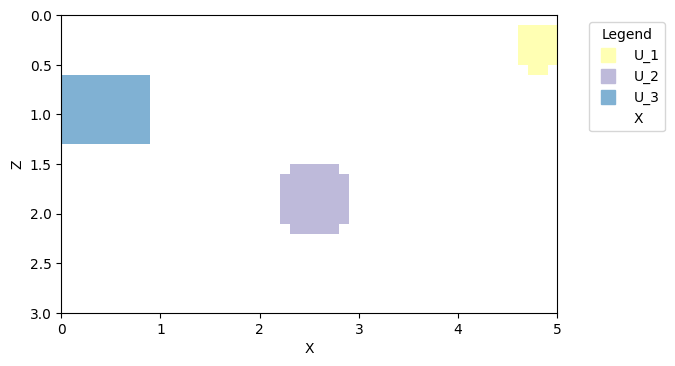

In [74]:
if len(util_lit_list)!=0:
    merged_util_lit = lithological_domain2d.LithologicalDomain2D_from_Utils2D(model_sett['x_span'], model_sett['z_span'], model_sett['del_xy_final'], model_sett['del_z_final'], 'util_merged', surfaceBoundaryCreator_class=surf)
    for util_lit in util_lit_list:
        merged_util_lit.merge_with_another_lithological_domain(util_lit)
    # lit.merge_with_another_lithological_domain(merged_util_lit)
merged_util_lit.plot2d()
merged_util_lit.utils_description


In [75]:
importlib.reload(f)
importlib.reload(material_domain2d)
mat_type_generator_dict = {'def': addn_props.addn_properties['soil_type'],
                           'U_': addn_props.addn_properties['utils_type']}

mat_dom = material_domain2d.MaterialDomain([lit, merged_util_lit], mat_type_generator_dict, main_props)

In [76]:
print(mat_dom.lit_id2material_dict)
mat_dom.get_all_sample_properties()
mat_dom.sampled_properties


{'1': ['def', 'Gravel'], '2': ['def', 'Weathered Rock'], '3': ['def', 'Gravel'], 'U_1': ['U_', 'Masonry'], 'U_2': ['U_', 'Flexible PVC'], 'U_3': ['U_', 'Steel']}


{'vs': {'1': {'both': {'mean': 412.25658098988595,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'},
   'layer0_air': {'mean': 0}},
  '2': {'both': {'mean': 997.4154549355885,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'},
   'layer0_air': {'mean': 0}},
  '3': {'both': {'mean': 306.3043289877957,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'},
   'layer0_air': {'mean': 0}},
  'U_1': {'both': {'mean': 1110.91047106482,
    'mean_bm': 0,
    'stdev/cov': 0,
    'stdev_type': 'cov'}},
  'U_2': {'both': {'mean': 179.34934789191976,
    'mean_bm': 0,
    'stdev/cov': 0,
    'stdev_type': 'cov'}},
  'U_3': {'both': {'mean': 3160.166133690086,
    'mean_bm': 0,
    'stdev/cov': 0,
    'stdev_type': 'cov'}}},
 'miu': {'1': {'wet': {'mean': 0.47097080371712946,
    'mean_bm': 0,
    'stdev/cov': 0,
    'stdev_type': 'cov'},
   'dry': {'mean': 0.22984936389745791,
    'mean_bm': 0,
    'stdev/cov': 0,
    'stdev_type': 'cov'},
   'layer0_ai

In [77]:
lit.layered_matrix.shape

(15, 25)

In [99]:
importlib.reload(generated_profiles2d)
importlib.reload(spatial_simulation2d)
importlib.reload(f)
gen_profile = generated_profiles2d.GeneratedProfiles2D(mat_dom, model_sett['spatial_theta_x'], model_sett['spatial_theta_z'], rnd_gen)
gen_profile.generate_spatial('vs', min_val = soil_sett['min_vs'])
gen_profile.generate_spatial('miu')

Simulating z-vals for Layer ID: 1
Simulating z-vals for Layer ID: 2
Simulating z-vals for Layer ID: 3
(15, 25) (15, 25)
(30, 50)
Simulating z-vals for Layer ID: U_1
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: U_3
Simulating z-vals for Layer ID: X
(30, 50) (30, 50)
(30, 50)
Simulating z-vals for Layer ID: 1
Simulating z-vals for Layer ID: 2
Simulating z-vals for Layer ID: 3
(15, 25) (15, 25)
(30, 50)
Simulating z-vals for Layer ID: U_1
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: U_3
Simulating z-vals for Layer ID: X
(30, 50) (30, 50)
(30, 50)


(<Axes: >, 0.21649793548444246, 0.75)

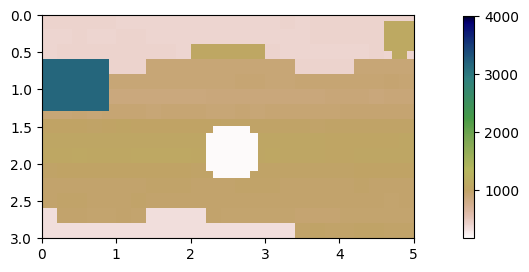

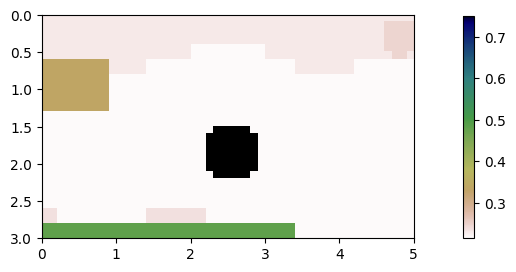

In [100]:
gen_profile.plot2d('vs',  vmin=None, vmax=4000)
gen_profile.plot2d('miu')

In [20]:
gen_profile.generate_spatial('z_val2', generate_z_vals = True)

Simulating z-vals for Layer ID: 1
Simulating z-vals for Layer ID: 2
Simulating z-vals for Layer ID: 3
Simulating z-vals for Layer ID: U_1
Simulating z-vals for Layer ID: X


(<Axes3D: title={'center': 'Section at X = 5, Y = 0, and Z = 0'}, xlabel='X [m]', ylabel='Y [m]', zlabel='Z [m]'>,
 np.float64(-1.8530032377342474),
 np.float64(2.0507234868966826))

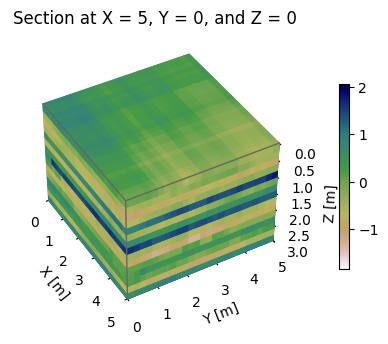

In [21]:
gen_profile.plot3d('z_val2')